# `GaussianWavePacket` — Paquet d’ondes gaussien

**Fichier source :** `src/quantum_sim/waves/gaussian_wave_packet.py`

---

## 1. Contexte physique

Un **paquet d’ondes gaussien** est une superposition d’ondes planes dont les amplitudes sont pondérées par une gaussienne en espace des nombres d’onde $k$.

C’est un modèle central en mécanique quantique car il permet de représenter une particule **localisée** dans l’espace, contrairement à l’onde plane pure (délocalisée).

## 2. Formulation mathématique

Le paquet discret implémenté ici s’écrit :

$$
\psi(x,t) = \sum_{n=1}^{N} A_n \exp\left(i\left[k_n(x-x_0) - \omega_n t\right]\right)
$$

avec des amplitudes gaussiennes :

$$
A_n = \exp\left(-\frac{(k_n-k_0)^2}{2\sigma_k^2}\right)
$$

où :
- $k_0$ est le nombre d’onde central,
- $\sigma_k$ fixe la largeur en espace impulsionnel,
- $N$ est le nombre de composantes discrètes.

La fenêtre utilisée dans le code est $[k_0-4\sigma_k,\,k_0+4\sigma_k]$, ce qui couvre pratiquement toute la masse d’une gaussienne.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from quantum_sim.waves.gaussian_wave_packet import GaussianWavePacket
from quantum_sim.utils.constants import ELECTRON_MASS, REDUCED_PLANCK_CONSTANT

np.set_printoptions(precision=3, suppress=True)

## 3. Idée d’implémentation

La classe `GaussianWavePacket` hérite de `WavePacket` et automatise trois étapes :

1. Construction d’une grille de nombres d’onde `k_values` autour de $k_0$.
2. Calcul des amplitudes gaussiennes associées.
3. Création d’une liste de `PlaneWave` puis appel du constructeur parent `WavePacket`.

Ce design réutilise toute l’API de `WavePacket` (`evaluate`, `normalize`, `probability_density`, `energy`, etc.) tout en fournissant une façon simple de générer un paquet réaliste.

In [2]:
import numpy as np
from quantum_sim.utils.constants import ELECTRON_MASS
from quantum_sim.waves.wave_packet import WavePacket
from quantum_sim.waves.plane_wave import PlaneWave


class GaussianWavePacket(WavePacket):
    """
    Gaussian wave packet: superposition of plane waves with a gaussian envelope.
    The amplitudes of the underlying plane waves are weighted by a Gaussian distribution
    in the momentum (k) space.
    """

    def __init__(
        self,
        k_center: float,
        sigma_k: float,
        n_waves: int = 100,
        position_center: float = 0.0,
        time: float = 0.0,
        mass: float = ELECTRON_MASS,
    ):
        if sigma_k <= 0:
            raise ValueError("sigma_k must be positive")
        if n_waves <= 0:
            raise ValueError("n_waves must be a positive integer")

        self.k0 = k_center
        self.sigma_k = sigma_k

        # Domaine en k: ~99.99% d'une gaussienne dans ±4σ
        k_min = k_center - 4 * sigma_k
        k_max = k_center + 4 * sigma_k
        k_values = np.linspace(k_min, k_max, n_waves)

        # Enveloppe gaussienne en espace impulsionnel
        amplitudes = np.exp(-((k_values - k_center) ** 2) / (2 * sigma_k**2))

        plane_waves = []
        for k, amp in zip(k_values, amplitudes):
            pw = PlaneWave(
                amplitude=amp,
                wave_number=k,
                position=position_center,
                masse=mass,
            )
            plane_waves.append(pw)

        super().__init__(plane_waves=plane_waves, time=time)

    def _gaussian_envelope(self, k: float) -> complex:
        return np.exp(-((k - self.k0) ** 2) / (2 * self.sigma_k**2))

## 4. Construction et propriétés principales

On crée un paquet d’onde gaussien d’électron puis on inspecte ses composantes impulsionnelles et son énergie moyenne.

In [3]:
k0 = 8e9
sigma_k = 8e8
n_waves = 101

gwp = GaussianWavePacket(
    k_center=k0,
    sigma_k=sigma_k,
    n_waves=n_waves,
    position_center=0.0,
    time=0.0,
    mass=ELECTRON_MASS,
)

v_g = REDUCED_PLANCK_CONSTANT * k0 / ELECTRON_MASS  # estimation particule libre

print("=== GaussianWavePacket ===")
print(f"Nombre de composantes : {len(gwp.plane_waves)}")
print(f"k0                   : {gwp.k0:.3e} m^-1")
print(f"sigma_k              : {gwp.sigma_k:.3e} m^-1")
print(f"<E>                  : {gwp.energy:.3e} J")
print(f"<E>                  : {gwp.energy / 1.602176634e-19:.3f} eV")
print(f"v_g ~ ħk0/m          : {v_g:.3e} m/s")

print("\nPremières composantes (k, A):")
for k, a in gwp.momentum_components()[:5]:
    print(f"k={k:.3e} m^-1, A={a:.3f}")

=== GaussianWavePacket ===
Nombre de composantes : 101
k0                   : 8.000e+09 m^-1
sigma_k              : 8.000e+08 m^-1
<E>                  : 3.926e-19 J
<E>                  : 2.451 eV
v_g ~ ħk0/m          : 9.261e+05 m/s

Premières composantes (k, A):
k=4.800e+09 m^-1, A=0.000
k=4.864e+09 m^-1, A=0.000
k=4.928e+09 m^-1, A=0.001
k=4.992e+09 m^-1, A=0.001
k=5.056e+09 m^-1, A=0.001


## 5. Évaluation spatiale et normalisation

Avant normalisation, la norme n’est pas garantie à 1. La méthode `normalize(start, end, points)` ajuste un facteur global pour imposer :

$$
\int |\psi(x)|^2 \, dx = 1
$$

sur l’intervalle numérique choisi.

Norme avant normalisation : 2.175128e-06
Norme après normalisation : 1.000000e+00


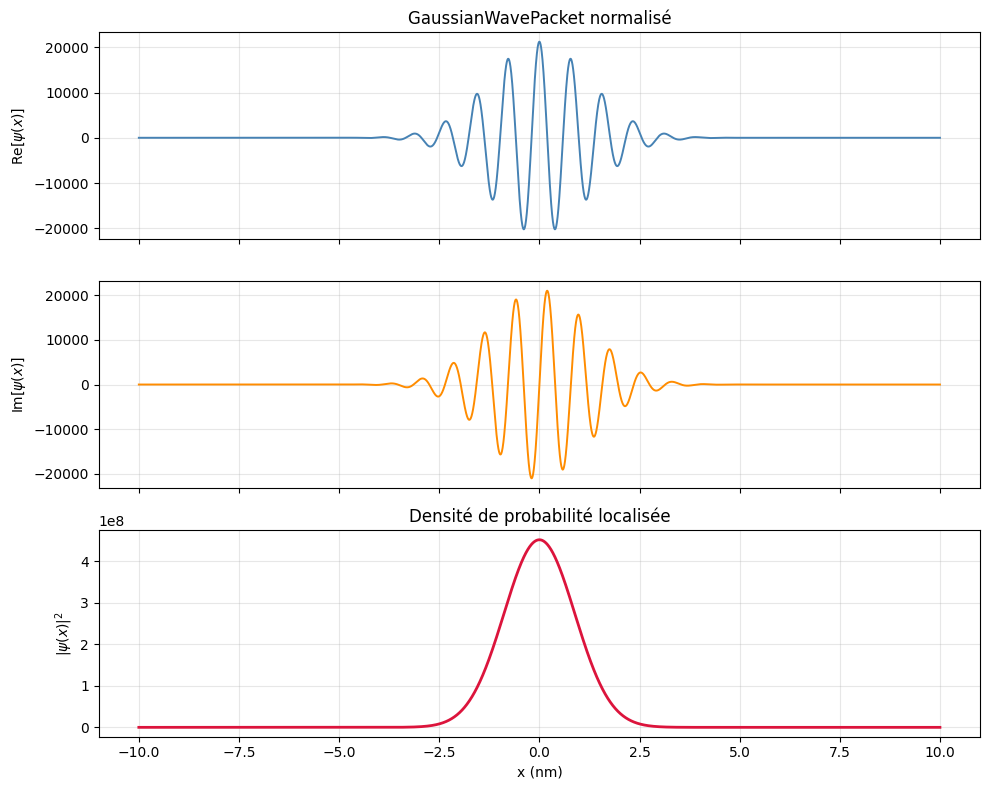

In [4]:
x = np.linspace(-10e-9, 10e-9, 5000)

psi_raw = gwp.evaluate(x)
rho_raw = np.abs(psi_raw)**2
norm_raw = np.trapezoid(rho_raw, x)

gwp.normalize(start=x[0], end=x[-1], points=len(x))
psi_norm = gwp.evaluate(x)
rho_norm = np.abs(psi_norm)**2
norm_norm = np.trapezoid(rho_norm, x)

print(f"Norme avant normalisation : {norm_raw:.6e}")
print(f"Norme après normalisation : {norm_norm:.6e}")

fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

axes[0].plot(x*1e9, psi_norm.real, color='steelblue', lw=1.4)
axes[0].set_ylabel(r'Re$[\psi(x)]$')
axes[0].set_title("GaussianWavePacket normalisé")
axes[0].grid(True, alpha=0.3)

axes[1].plot(x*1e9, psi_norm.imag, color='darkorange', lw=1.4)
axes[1].set_ylabel(r'Im$[\psi(x)]$')
axes[1].grid(True, alpha=0.3)

axes[2].plot(x*1e9, rho_norm, color='crimson', lw=2)
axes[2].set_xlabel('x (nm)')
axes[2].set_ylabel(r'$|\psi(x)|^2$')
axes[2].set_title('Densité de probabilité localisée')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Dispersion temporelle

Chaque composante en $k$ a sa propre pulsation $\omega(k)$, ce qui fait évoluer la forme du paquet dans le temps (dispersion).

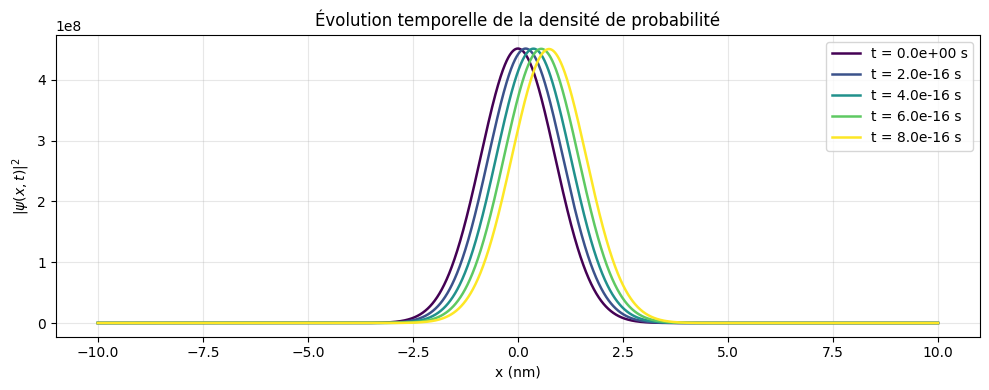

In [5]:
times = np.linspace(0, 8e-16, 5)
colors = plt.cm.viridis(np.linspace(0, 1, len(times)))

fig, ax = plt.subplots(figsize=(10, 4))
for t, c in zip(times, colors):
    psi_t = gwp.evaluate(x, t=t)
    ax.plot(x*1e9, np.abs(psi_t)**2, color=c, lw=1.8, label=f't = {t:.1e} s')

ax.set_xlabel('x (nm)')
ax.set_ylabel(r'$|\psi(x,t)|^2$')
ax.set_title('Évolution temporelle de la densité de probabilité')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

## 7. Résumé des éléments `GaussianWavePacket`

| Élément | Rôle |
|---|---|
| `k_center` | Nombre d’onde central $k_0$ |
| `sigma_k` | Largeur gaussienne en espace $k$ |
| `n_waves` | Nombre de composantes planes discrètes |
| `position_center` | Position initiale commune des composantes |
| `mass` | Masse utilisée pour $\omega = \hbar k^2/(2m)$ |
| Héritage `WavePacket` | Fournit `evaluate`, `normalize`, `energy`, `probability_density` |

En pratique, `GaussianWavePacket` est un **constructeur spécialisé** de `WavePacket` : il encapsule la génération gaussienne des composantes, puis délègue l’évaluation et la normalisation à la classe parente.